In [1]:
import sionna.rt
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
no_preview = False
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera, PathSolver, RadioMapSolver, subcarrier_frequencies 

jitc_llvm_init(): LLVM API initialization failed ..


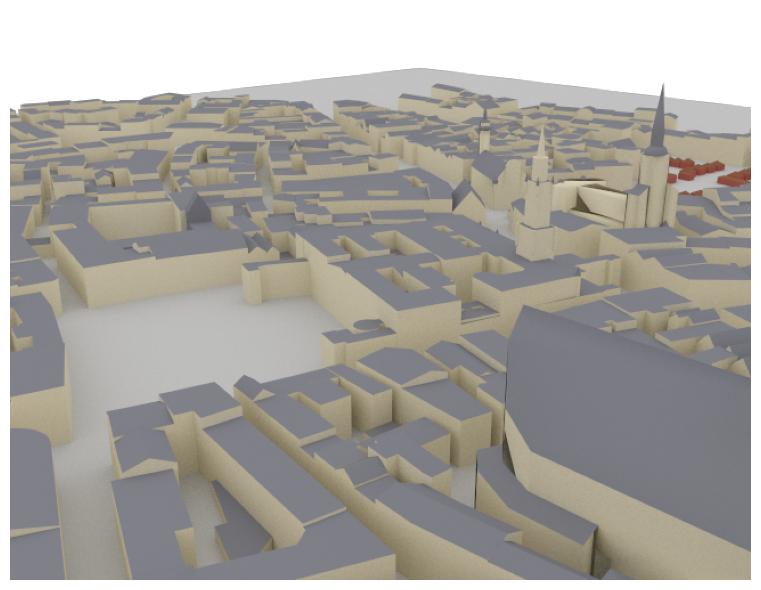

In [2]:
scene = load_scene(sionna.rt.scene.munich, merge_shapes=True)

if not no_preview:
    scene.preview()

# Create new camera with different configuration
my_cam = Camera(position=[-250,250,150], look_at=[-15,30,28])

# Render scene with new camera*
scene.render(camera=my_cam, resolution=[650, 500], num_samples=512);

In [3]:

# Configure antenna arrays
scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='tr38901',
                             polarization='V')

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='dipole',
                             polarization='cross')

scene.frequency = 3.5e9

# Create transmitter
tx = Transmitter(name="tx",
                position=[8.5,21,27],
                display_radius=2)

# Create receiver 1
rx = Receiver(name="rx",
              position = [80,90,1.5],
              display_radius=2)
rx2 = Receiver(name="rx2",
               position = [40,60,1.5],
               display_radius=2)

# Add to scene
scene.add(tx)
scene.add(rx)
scene.add(rx2)

In [4]:
# Initialize path solver
path_solver = PathSolver()

# Compute propagation paths for both receivers
paths = path_solver(scene = scene,
                    max_depth=5,
                    los = True,
                    specular_reflection = True,
                    diffuse_reflection = True,
                    refraction = True,
                    synthetic_array = False,
                    seed = 41)


# Compute channel impulse response
a, tau = paths.cir(normalize_delays=True, out_type="numpy")

# Compute discrete channel taps
taps = paths.taps(bandwidth=100e6,
                  l_min = -6,
                  l_max = 100,
                  sampling_frequency=None,
                  normalize_delays=True,
                  out_type="numpy")

# OFDM system parameters
num_subcarriers = 1024
subcarrier_spacing = 30e3

# Compute frequencies
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

# Compute channel frequency response
h_freq = paths.cfr(frequencies = frequencies,
                   normalize = True,
                   normalize_delays = True,
                   out_type = "numpy")

In [5]:
if no_preview:
    scene.render(camera=my_cam, paths=paths, clip_at=20);
else:
    scene.preview(paths=paths, clip_at=20);

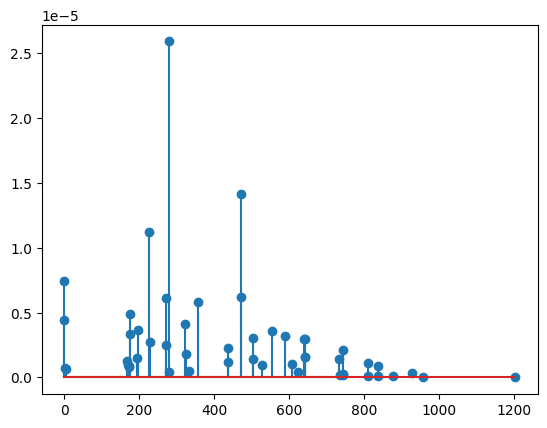

In [6]:
for rx_idx in range(2):

    tau_plot = tau[rx_idx,0,0,0,:]
    a_plot = np.abs(a[rx_idx,0,0,0,:,0])

    valid = tau_plot >= 0

    tau_plot = tau_plot[valid]
    a_plot = a_plot[valid]

    plt.stem(tau_plot*1e9,
             a_plot,
             label=f"rx{rx_idx}")

In [7]:
print("a shape :", a.shape)
print("tau shape :", tau.shape)

print("tau min :", np.min(tau))
print("tau max :", np.max(tau))

print(tau[0,0,0,0,:10])

a shape : (2, 1, 1, 2, 35, 1)
tau shape : (2, 1, 1, 2, 35)
tau min : -1.0
tau max : 1.202625e-06
[0.0000000e+00 1.7336589e-07 1.6726869e-07 1.7320127e-07 7.3366937e-07
 1.7494705e-07 1.6903471e-07 7.3450690e-07 1.7511104e-07 2.6237501e-09]
